<a href="https://colab.research.google.com/github/Kriti-2180/Deep-Learning/blob/main/ImproveStudentPass_FailNeuralNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
n_samples = 1000

study_hours = np.random.uniform(0, 10, n_samples)
sleep_hours = np.random.uniform(4, 9, n_samples)
attendance = np.random.uniform(40, 100, n_samples)

X = np.column_stack([
    study_hours,
    sleep_hours,
    attendance
])

score = (
    0.5 * study_hours
    + 0.2 * sleep_hours
    + 0.05 * attendance
)

y = (score > 7).astype(float)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
basic_model = Sequential([
    Dense(4, activation='sigmoid', input_shape=(3,)),
    Dense(1, activation='sigmoid')
])

basic_model.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

basic_history = basic_model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    verbose=0
)

basic_loss, basic_acc = basic_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[:, 0] = X_train_scaled[:, 0] / 10
X_train_scaled[:, 1] = X_train_scaled[:, 1] / 10
X_train_scaled[:, 2] = X_train_scaled[:, 2] / 100

X_test_scaled[:, 0] = X_test_scaled[:, 0] / 10
X_test_scaled[:, 1] = X_test_scaled[:, 1] / 10
X_test_scaled[:, 2] = X_test_scaled[:, 2] / 100

In [7]:
improved_model = Sequential([
    Dense(16, activation='relu', input_shape=(3,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

improved_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

improved_history = improved_model.fit(
    X_train_scaled,
    y_train,
    epochs=200,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop],
    verbose=1
)

improved_loss, improved_acc = improved_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.2812 - loss: 0.7233 - val_accuracy: 0.3550 - val_loss: 0.7068
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5138 - loss: 0.6852 - val_accuracy: 0.5100 - val_loss: 0.6793
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5512 - loss: 0.6638 - val_accuracy: 0.5100 - val_loss: 0.6653
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5675 - loss: 0.6469 - val_accuracy: 0.5750 - val_loss: 0.6498
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6325 - loss: 0.6285 - val_accuracy: 0.6650 - val_loss: 0.6323
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7075 - loss: 0.6087 - val_accuracy: 0.6800 - val_loss: 0.6121
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7425 - loss: 0.5874 - val_accuracy: 0.7200 - val_loss: 0.5905
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7688 - loss: 0.5652 - val_accuracy: 0.7350 - 

In [8]:
print("Basic Model Accuracy:", basic_acc)
print("Improved Model Accuracy:", improved_acc)

print("\nBasic Model Loss:", basic_loss)
print("Improved Model Loss:", improved_loss)

Basic Model Accuracy: 0.5099999904632568
Improved Model Accuracy: 0.9950000047683716

Basic Model Loss: 0.6964172124862671
Improved Model Loss: 0.038972608745098114


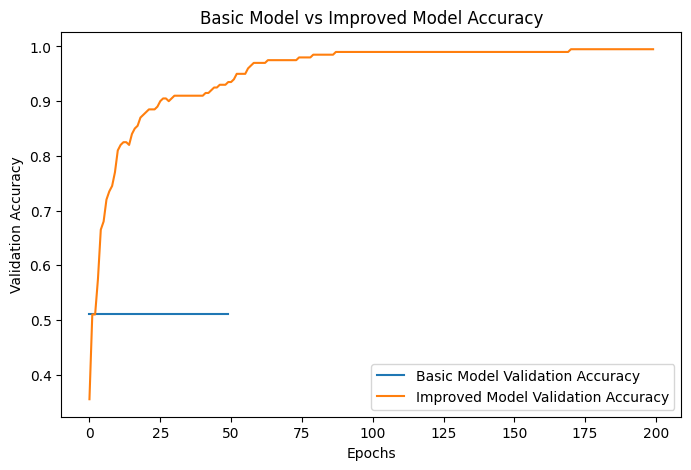

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    basic_history.history['val_accuracy'],
    label='Basic Model Validation Accuracy'
)

plt.plot(
    improved_history.history['val_accuracy'],
    label='Improved Model Validation Accuracy'
)

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Basic Model vs Improved Model Accuracy")

plt.legend()
plt.show()

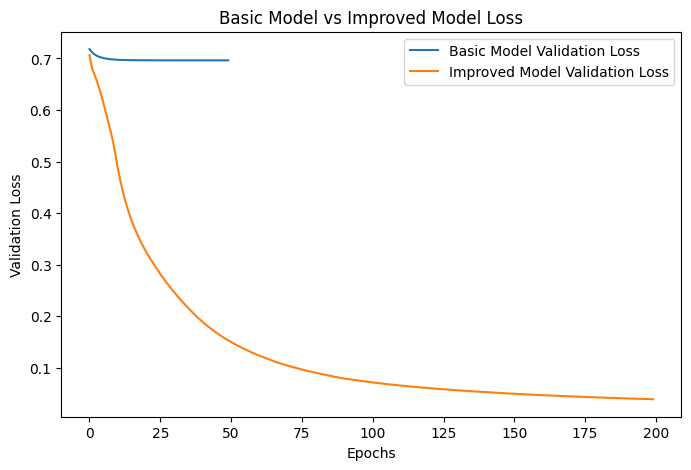

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    basic_history.history['val_loss'],
    label='Basic Model Validation Loss'
)

plt.plot(
    improved_history.history['val_loss'],
    label='Improved Model Validation Loss'
)

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Basic Model vs Improved Model Loss")

plt.legend()
plt.show()

In [11]:
student = np.array([[6, 7, 85]], dtype=float)

student_scaled = student.copy()

student_scaled[:, 0] = student_scaled[:, 0] / 10
student_scaled[:, 1] = student_scaled[:, 1] / 10
student_scaled[:, 2] = student_scaled[:, 2] / 100

prediction = improved_model.predict(student_scaled)

print("Prediction Probability:", prediction[0][0])

if prediction[0][0] >= 0.5:
    print("Prediction: PASS")
else:
    print("Prediction: FAIL")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
Prediction Probability: 0.9999976
Prediction: PASS
